## Speech Signal DSP Pipeline in Python

This notebook demonstrates a complete **speech signal DSP preprocessing pipeline** using Python. We start from a raw speech waveform and go through:

1. **Raw Signal Analysis**
2. **FFT (Frequency Spectrum)**
3. **Spectrogram (STFT)**
4. **Band-pass FIR Filter Design (300–3400 Hz)**
5. **Filtering and Comparison (before vs after)**
6. **Framing of the speech signal**
7. **Windowing with a Hamming window**
8. **Feature Extraction (MFCC, spectral centroid, ZCR, band energy)**

The goal is to illustrate typical preprocessing steps used before feeding speech signals into machine learning models.

In [50]:
# Imports and global configuration
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy import signal

# Display plots inline and set a consistent style
plt.style.use("seaborn-v0_8-darkgrid")

# Path to the speech file (update this to your file path)
# audio_path = "audio.wav"  # e.g., "data/speech_example.wav"
audio_path = "../data/voice2.m4a"  # <-- change this to your .wav file

# Convenience plotting helpers

def plot_waveform(y, sr, title="Waveform", xlim=None):
    """Plot time-domain waveform."""
    t = np.arange(len(y)) / sr
    plt.figure(figsize=(10, 3))
    plt.plot(t, y, color='steelblue', alpha=0.8)
    plt.title(title)
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    if xlim is not None:
        plt.xlim(xlim)
    plt.tight_layout()
    plt.show()

def plot_spectrum(y, sr, title="Magnitude Spectrum"):
    """Plot single-sided magnitude spectrum using FFT."""
    N = len(y)
    Y = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(N, d=1.0 / sr)
    mag = 10 * np.log10(np.abs(Y) + 1e-9) # Chuyển sang dB để dễ quan sát

    plt.figure(figsize=(10, 3))
    plt.plot(freqs, mag)
    plt.title(title)
    plt.xlabel("Frequency [Hz] - Log Scale")
    plt.ylabel("Magnitude [dB]")
    
    # Thiết lập trục X dạng logarit
    plt.xscale('log')
    plt.xlim(20, sr / 2) # Giới hạn từ 20Hz đến tần số Nyquist
    plt.grid(True, which="both", ls="-", alpha=0.5)
    
    plt.tight_layout()
    plt.show()

def plot_spectrogram(y, sr, title="Spectrogram", n_fft=1024, hop_length=256):
    """Compute and plot a log-magnitude spectrogram using STFT."""
    # Tính STFT và chuyển sang dB
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
    S_db = librosa.amplitude_to_db(S, ref=np.max)

    plt.figure(figsize=(10, 4))
    
    # Thay y_axis="linear" bằng "log"
    # Điều này sẽ tự động chuyển trục Y sang logarit và gắn nhãn Hz
    img = librosa.display.specshow(S_db, sr=sr, hop_length=hop_length,
                                   x_axis="time", y_axis="log")
    
    plt.colorbar(img, format="%+2.0f dB")
    
    # Lưu ý: Với y_axis='log', librosa mặc định bắt đầu từ ~0Hz 
    # Nếu muốn giới hạn cụ thể (ví dụ 20Hz - 20kHz):
    plt.ylim(20, sr/2) 
    
    plt.title(title)
    plt.tight_layout()
    plt.show()

### 1. Load and Analyze Raw Signal

In this section we:

- **Load** a speech waveform from disk using `librosa`.
- **Inspect** the sampling rate and duration.
- **Visualize** the waveform in the time domain, including a **zoomed-in segment**.

The waveform represents how the air pressure (captured by the microphone) varies over time. For voiced speech, you can often see quasi-periodic structure corresponding to vocal fold vibrations.

Sampling rate: 48000 Hz
Duration: 6.93 seconds


/var/folders/2v/t3z6y_ss25s2_drm51xk26t80000gn/T/ipykernel_40346/1810110306.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=None, mono=True)
/Users/ethanhuang/Projects/DSP501-Speaker-Identification-Project/.venv/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


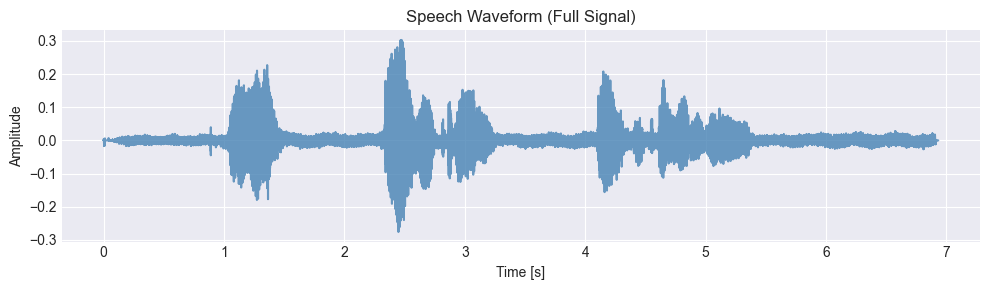

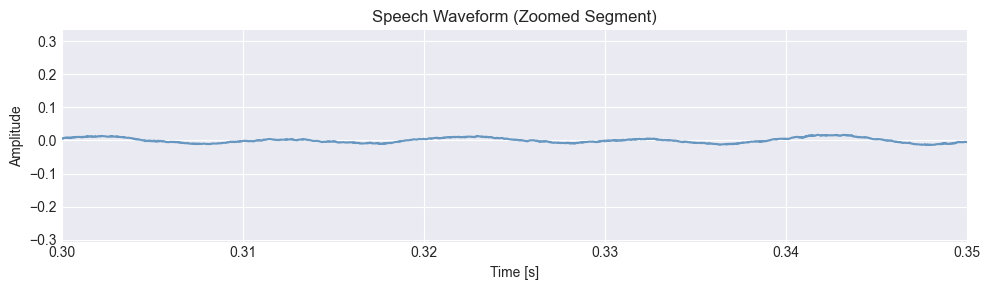

In [51]:
# 1. Load and analyze raw signal

# Load audio (mono). Set sr=None to keep the original sampling rate.
y, sr = librosa.load(audio_path, sr=None, mono=True)

# Basic information about the signal
duration = len(y) / sr
print(f"Sampling rate: {sr} Hz")
print(f"Duration: {duration:.2f} seconds")

# Plot full waveform
plot_waveform(y, sr, title="Speech Waveform (Full Signal)")

# Plot a zoomed-in segment (e.g., first 50 ms)
zoom_start_sec = 0.3  # you can adjust these values
zoom_end_sec = 0.35
plot_waveform(y, sr, title="Speech Waveform (Zoomed Segment)",
              xlim=(zoom_start_sec, zoom_end_sec))

### 2. FFT Analysis (Frequency Spectrum)

We now analyze the signal in the **frequency domain** using the Fast Fourier Transform (FFT):

- Compute the **single-sided magnitude spectrum**.
- Plot **magnitude vs frequency**.

For voiced speech, you typically see:

- A strong **low-frequency fundamental** (pitch) component.
- **Harmonics** (integer multiples of the fundamental).
- Most speech energy concentrated below a few kilohertz.

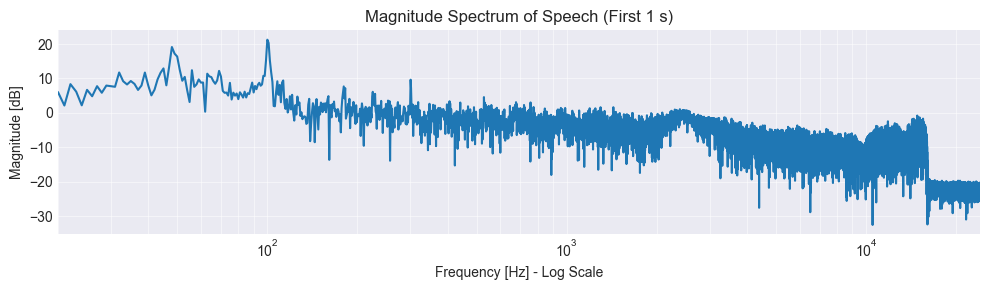

In [52]:
# 2. FFT analysis (frequency spectrum)

# Optionally, we can analyze a shorter segment to better see spectral details
segment_duration_sec = 1.0  # analyze first 1 second
N_seg = int(min(len(y), segment_duration_sec * sr))
y_seg = y[:N_seg]

plot_spectrum(y_seg, sr, title="Magnitude Spectrum of Speech (First 1 s)")

### 3. Spectrogram (STFT)

Next we compute the **Short-Time Fourier Transform (STFT)** to obtain a **spectrogram**:

- The spectrogram is a **time–frequency representation**.
- Each column corresponds to one short-time frame of the signal.
- It shows how **speech energy changes over time and frequency**, allowing us to see phonemes, formants, and transitions.

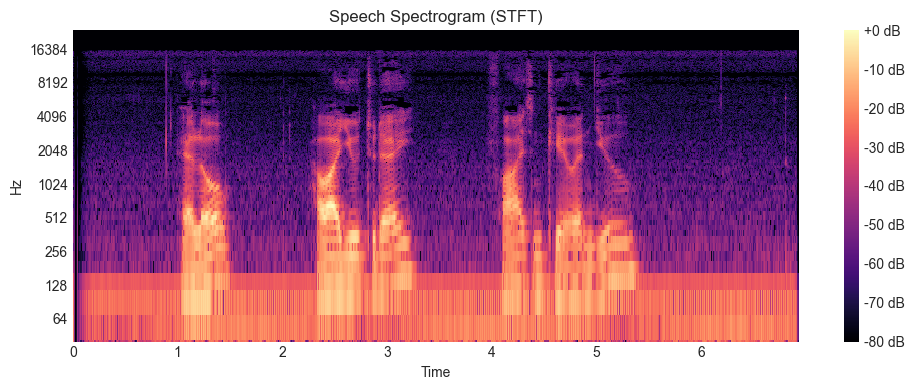

In [53]:
# 3. Spectrogram (STFT)

n_fft = 1024
hop_length = 256

plot_spectrogram(y, sr, title="Speech Spectrogram (STFT)",
                 n_fft=n_fft, hop_length=hop_length)

### 4. Design Band-Pass FIR Filter (300–3400 Hz)

We now design a **band-pass FIR filter** that passes the main speech band:

- **Passband**: 300–3400 Hz (typical telephone speech range).
- Designed using `scipy.signal.firwin`.
- FIR length: between 101–201 taps (here we choose 151 taps).

This range is used because:

- **Below 300 Hz**: contains very low-frequency noise and little important speech information.
- **Above 3400 Hz**: contains high-frequency noise; many speech intelligibility cues are already captured below this range.

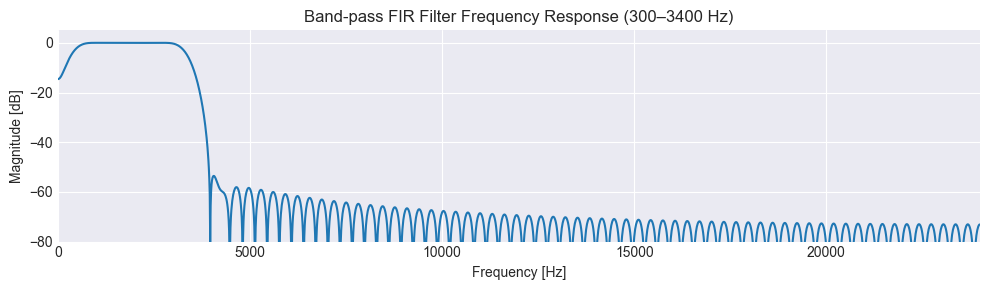

In [54]:
# 4. Design band-pass FIR filter

# Filter design parameters
num_taps = 151  # filter length (number of coefficients)
low_cut = 300.0
high_cut = 3400.0
nyq = sr / 2.0

# Normalized cutoff frequencies for firwin
bands = [low_cut / nyq, high_cut / nyq]

# Design band-pass FIR filter using a Hamming window
b = signal.firwin(num_taps, bands, pass_zero=False, window="hamming")

# Frequency response of the filter
w, h = signal.freqz(b, worN=2048)
freqs = w * nyq / np.pi

plt.figure(figsize=(10, 3))
plt.plot(freqs, 20 * np.log10(np.maximum(np.abs(h), 1e-8)))
plt.title("Band-pass FIR Filter Frequency Response (300–3400 Hz)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.xlim(0, nyq)
plt.ylim(-80, 5)
plt.tight_layout()
plt.show()

### 5. Apply Filter and Compare Signals

We now apply the designed **band-pass FIR filter** to the speech signal using `scipy.signal.lfilter`.

We compare **before vs after filtering** using:

- **Waveform comparison**.
- **Magnitude spectrum comparison**.
- **Spectrogram comparison**.

Filtering should **attenuate noise and components outside 300–3400 Hz**, while preserving the main speech information.

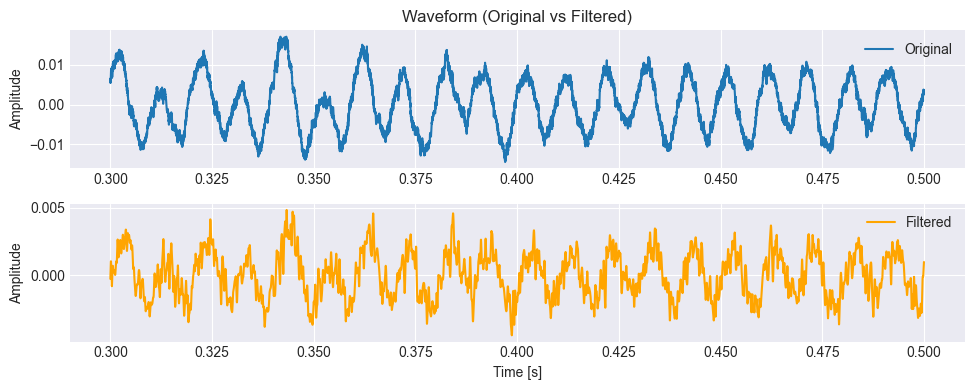

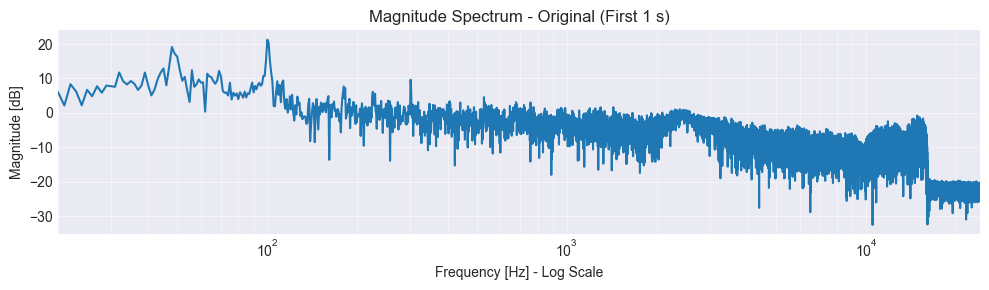

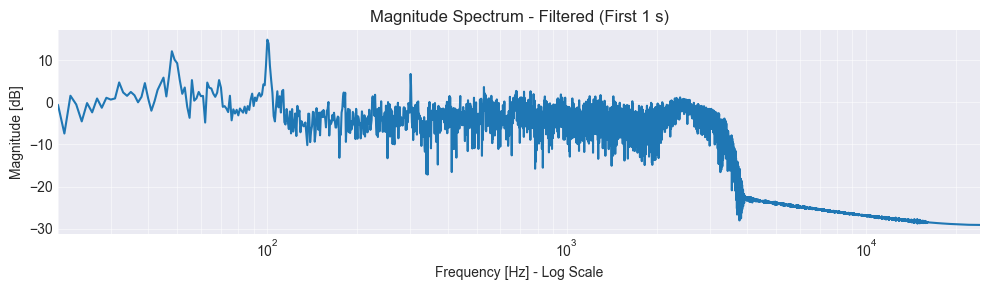

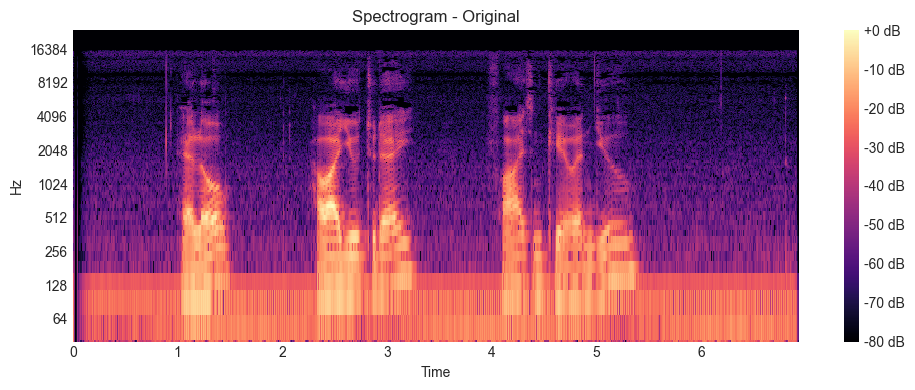

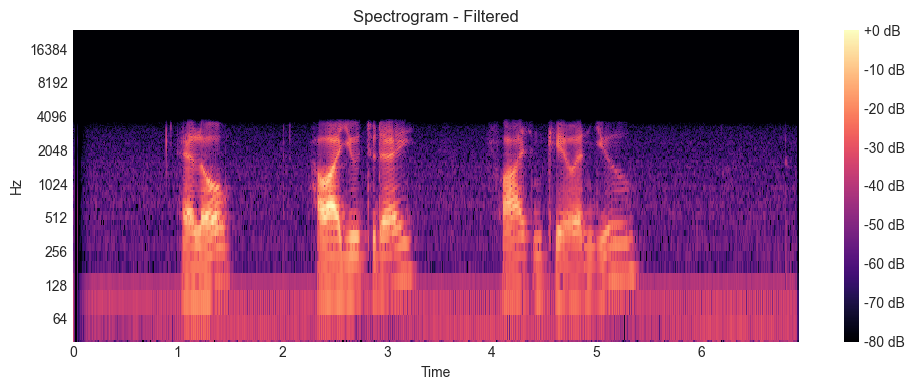

In [55]:
# 5. Apply filter and compare signals

# Apply FIR filter
y_filt = signal.lfilter(b, 1.0, y)

# Waveform comparison (short segment for clarity)
comp_start_sec = 0.3
comp_end_sec = 0.5

plt.figure(figsize=(10, 4))

plt.subplot(2, 1, 1)
plot_range = (int(comp_start_sec * sr), int(comp_end_sec * sr))
t = np.arange(len(y)) / sr
plt.plot(t[plot_range[0]:plot_range[1]], y[plot_range[0]:plot_range[1]], label="Original")
plt.title("Waveform (Original vs Filtered)")
plt.ylabel("Amplitude")
plt.legend(loc="upper right")

plt.subplot(2, 1, 2)
plt.plot(t[plot_range[0]:plot_range[1]], y_filt[plot_range[0]:plot_range[1]], color="orange", label="Filtered")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

# Spectrum comparison (use the same 1-second segment as before)
plot_spectrum(y_seg, sr, title="Magnitude Spectrum - Original (First 1 s)")

# Filter the same segment for fair comparison
y_seg_filt = signal.lfilter(b, 1.0, y_seg)
plot_spectrum(y_seg_filt, sr, title="Magnitude Spectrum - Filtered (First 1 s)")

# Spectrogram comparison
plot_spectrogram(y, sr, title="Spectrogram - Original", n_fft=n_fft, hop_length=hop_length)
plot_spectrogram(y_filt, sr, title="Spectrogram - Filtered", n_fft=n_fft, hop_length=hop_length)

### 6. Framing

Speech is commonly processed in **short-time frames** where the signal can be assumed **quasi-stationary**.

Here we:

- Use **25 ms frame length** and **10 ms hop length**.
- Split the filtered speech signal into overlapping frames.
- Visualize one example frame in the time domain.

Within such short windows, the vocal tract configuration and excitation are approximately constant, which justifies many time–frequency processing techniques.

### 7. Windowing (Hamming Window)

To reduce **spectral leakage** when we later analyze frames in the frequency domain, we apply a **window function**:

- Here we use the **Hamming window**.
- We show a frame **before and after windowing**.
- We also plot the window itself.

Without windowing, the abrupt truncation of the frame edges in time causes energy to spread across frequencies (spectral leakage). Windowing smooths the frame edges, reducing this effect.

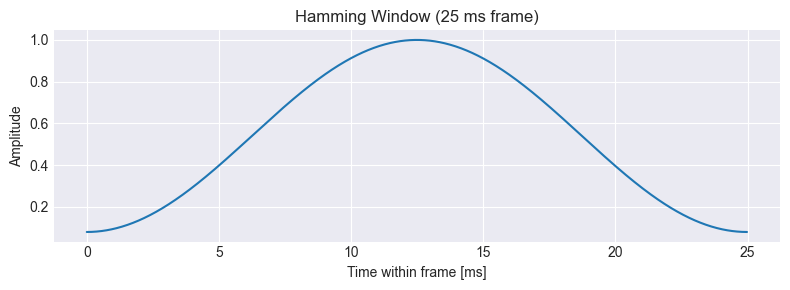

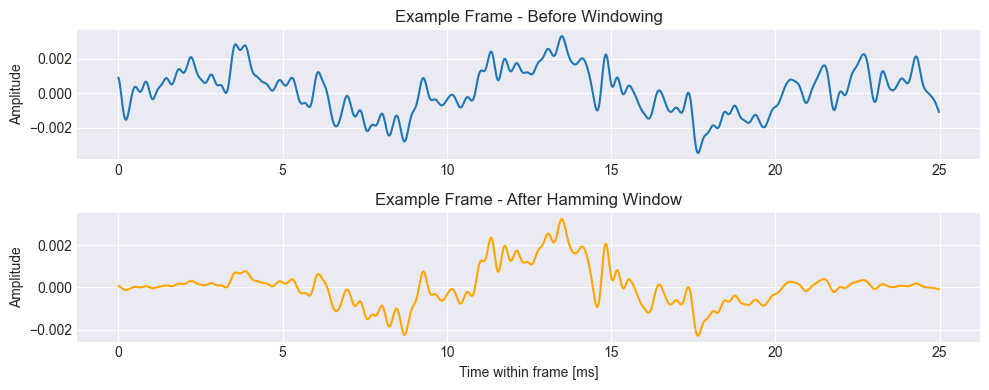

In [56]:
# 7. Windowing with a Hamming window

# Ensure frame parameters and example frame exist
frame_length_ms = 25.0
hop_length_ms = 10.0

frame_length = int(frame_length_ms * 1e-3 * sr)
hop_length_frames = int(hop_length_ms * 1e-3 * sr)

# Recreate frames on the filtered signal if not already available
frames = librosa.util.frame(y_filt, frame_length=frame_length, hop_length=hop_length_frames)
example_frame_idx = 50  # you can change this index
example_frame = frames[:, example_frame_idx]

t_frame = np.arange(frame_length) / sr

# Create Hamming window of frame length
hamming_win = np.hamming(frame_length)

# Apply window to the same example frame
example_frame_windowed = example_frame * hamming_win

# Plot window function
plt.figure(figsize=(8, 3))
plt.plot(t_frame * 1e3, hamming_win)
plt.title("Hamming Window (25 ms frame)")
plt.xlabel("Time within frame [ms]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Compare frame before and after windowing
plt.figure(figsize=(10, 4))

plt.subplot(2, 1, 1)
plt.plot(t_frame * 1e3, example_frame)
plt.title("Example Frame - Before Windowing")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(t_frame * 1e3, example_frame_windowed, color="orange")
plt.title("Example Frame - After Hamming Window")
plt.xlabel("Time within frame [ms]")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

### 8. Feature Extraction

Finally, we extract common **speech features** from the (filtered) signal using `librosa`:

- **MFCCs (Mel-Frequency Cepstral Coefficients)** – compactly describe the spectral envelope.
- **Spectral Centroid** – indicates where the "center of mass" of the spectrum is.
- **Zero Crossing Rate (ZCR)** – measures how often the signal changes sign (related to noisiness and voicing).
- **Band Energy (300–3400 Hz)** – energy limited to the speech band.

These features are widely used as inputs to machine learning models for speech and speaker recognition.

MFCC shape: (13, 650)
Spectral centroid shape: (1, 650)
ZCR shape: (1, 650)
Band energy shape: (1300,)


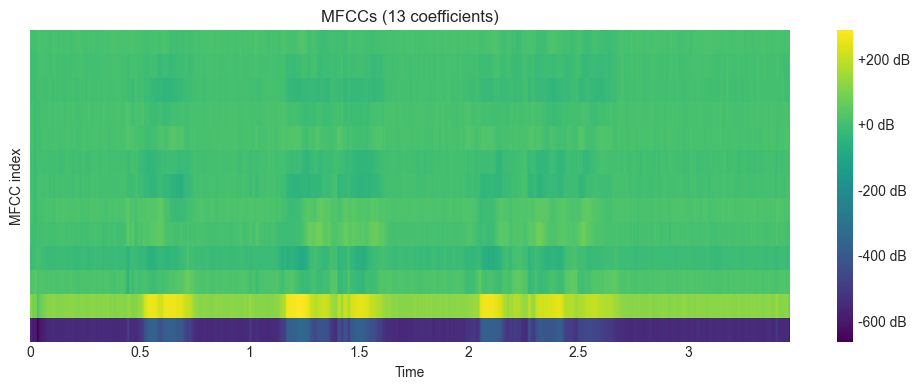

In [57]:
# 8. Feature extraction

# Use the filtered signal for feature extraction
y_feat = y_filt

# MFCCs (13 coefficients)
n_mfcc = 13
mfcc = librosa.feature.mfcc(y=y_feat, sr=sr, n_mfcc=n_mfcc)

# Spectral centroid
spec_centroid = librosa.feature.spectral_centroid(y=y_feat, sr=sr)

# Zero Crossing Rate (ZCR)
zcr = librosa.feature.zero_crossing_rate(y_feat)

# Band energy in 300–3400 Hz using STFT
n_fft_feat = 1024
hop_length_feat = 256
S = np.abs(librosa.stft(y_feat, n_fft=n_fft_feat, hop_length=hop_length_feat))
freqs_feat = librosa.fft_frequencies(sr=sr, n_fft=n_fft_feat)

band_mask = (freqs_feat >= low_cut) & (freqs_feat <= high_cut)
band_energy = S[band_mask, :].sum(axis=0)

print("MFCC shape:", mfcc.shape)           # (n_mfcc, num_frames)
print("Spectral centroid shape:", spec_centroid.shape)
print("ZCR shape:", zcr.shape)
print("Band energy shape:", band_energy.shape)

# Visualize MFCCs as a heatmap
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, x_axis="time", sr=sr, hop_length=hop_length_feat,
                         cmap="viridis")
plt.colorbar(format="%+2.0f dB")
plt.title("MFCCs (13 coefficients)")
plt.ylabel("MFCC index")
plt.tight_layout()
plt.show()

### Summary

In this notebook we implemented a complete **speech DSP preprocessing pipeline**:

- Inspected the raw waveform and its **FFT spectrum**.
- Visualized the **time–frequency structure** via a spectrogram.
- Designed and applied a **band-pass FIR filter** for the speech band (300–3400 Hz) and compared signals before and after filtering.
- Split the signal into **short-time frames**, applied **Hamming windowing**, and extracted representative **speech features** (MFCCs, spectral centroid, ZCR, and band energy) suitable as inputs to machine learning models.